In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
from mgdraw_output_reader_NOVO_vAMB import DetectionDataStorage
from helper_functions_2 import find_HU_group_info
from voxel_GT_composition import find_voxel_GT_composition

### Data loading for one file

In [2]:
data_path = r"D:\Study_spectroscopy\HNC_simulations\sim_3_5\scintillator_interactions"

file = DetectionDataStorage(folder_path = data_path, primaries_per_spawn = 5e6, max_files = 100)

file.load_data()
file.filter_hits(write_hits_to_file = True)

Reading 108 scintillator_interactions.txt-files


c:\Users\amibe\OneDrive\Documentos\GitHub\MedicalPhysicsScripts\NOVO\Spectroscopy\Data\mgdraw_output_reader_NOVO_vAMB.py:540: SyntaxWarning: invalid escape sequence '\ '
  """


KeyboardInterrupt: 

In [3]:
file.filter_hits(write_hits_to_file = True)


-----------ICODE FILTERING-----------
Raw hit filtering complete. Time used: 17.7 s
Total number of lines: 1187616
Number of lines kept: 287774 (24.2%)
Number of lines rejected: 899842 (75.8%)

-----------HIT MERGING-----------
Merging complete. Time used: 7.33 s
Overlaps found: 42670
Total number of hit histories > 10/200 keV: 164816
Number of gamma hit histories > 10 keV: 100856
Number of neutron hit histories > 200 keV: 63867
Number of combo hit histories > 200 keV: 93
D:/Study_spectroscopy/HNC_simulations/sim_0_0/gamma_hits.txt successfully created
D:/Study_spectroscopy/HNC_simulations/sim_0_0/neutron_hits.txt successfully created
D:/Study_spectroscopy/HNC_simulations/sim_0_0/all_hits.txt successfully created


In [2]:
gamma_hits_path = r"d:\Study_spectroscopy\HNC_simulations\sim_0_0\gamma_hits.txt"
'''
with open(gamma_hits_path, "r") as f:
    lines = f.readlines()
    num_hits = len(lines)
    num_elements = len(lines[0]) 
    hit_array = []
    for line in lines:
        elements = np.array(line.split()).astype(float)
        hit_array.append(elements)

hit_array = np.array(hit_array)'''

def get_gamma_hits(gamma_hits_path):
    
    with open(gamma_hits_path, "r") as f:
        lines = f.readlines()
        hit_array = []
        
        for line in lines:
            elements = np.array(line.split()).astype(float)
            if elements[4] == 1.0: # just for checking change in voxel comp 
                hit_array.append(elements)

    hit_array = np.array(hit_array)

    return hit_array

hit_array = get_gamma_hits(gamma_hits_path)

In [ ]:
energy_dep = hit_array[:,7]


### Plotting (for testing)

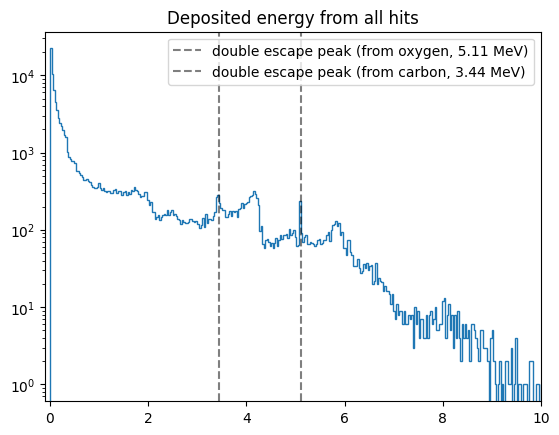

In [53]:
plt.figure()
plt.title("Deposited energy from all hits")

plt.hist(energy_dep, bins = 500, histtype = "step")
plt.axvline(x = 5.11, color = "black", linestyle = "--", alpha = 0.5, label = "double escape peak (from oxygen, 5.11 MeV)")
plt.axvline(x = 3.44, color = "black", linestyle = "--", alpha = 0.5, label = "double escape peak (from carbon, 3.44 MeV)")

plt.yscale("log")
plt.xlim(-0.1, 10)
plt.legend()

plt.show()

In [42]:
icodes = hit_array[:,1]
ncases = hit_array[:,0]
print(set(icodes))
print(len(ncases))
print(len(set(ncases)))


{np.float64(219.0), np.float64(221.0)}
100856
87716


In [48]:
# merge for ncase

energy_dep_merged = []
ncase_checked = []

# NB: fix to start at zero
for i in range(len(hit_array)):
    
    current_hit = hit_array[i]
    current_ncase = current_hit[0]
    
    # only for speed up
    if len(ncase_checked) < 100: 
        if current_ncase not in ncase_checked:
            energy_dep_merged.append(current_hit[7])
            ncase_checked.append(current_ncase)
        
        if current_ncase in ncase_checked:
            energy_dep_merged[-1] += current_hit[7]
    else:
        if current_ncase not in ncase_checked[-10:]:
            energy_dep_merged.append(current_hit[7])
            ncase_checked.append(current_ncase)
        
        if current_ncase in ncase_checked[-10:0]:
            energy_dep_merged[-1] += current_hit[7]

print(len(energy_dep_merged))






87716


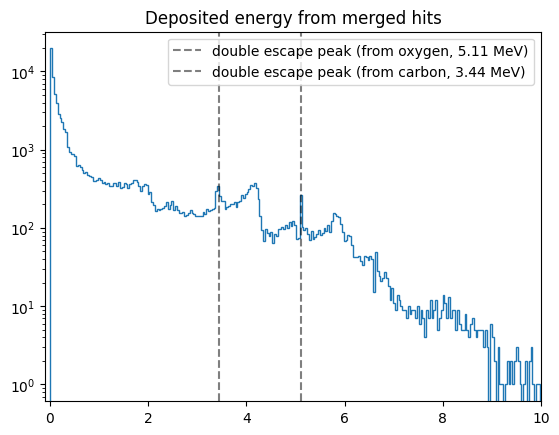

In [52]:
plt.figure()
plt.title("Deposited energy from merged hits")

plt.hist(energy_dep_merged, bins = 500, histtype = "step")
plt.axvline(x = 5.11, color = "black", linestyle = "--", alpha = 0.5, label = "double escape peak (from oxygen, 5.11 MeV)")
plt.axvline(x = 3.44, color = "black", linestyle = "--", alpha = 0.5, label = "double escape peak (from carbon, 3.44 MeV)")

plt.yscale("log")
plt.xlim(-0.1, 10)
plt.legend()
plt.show()

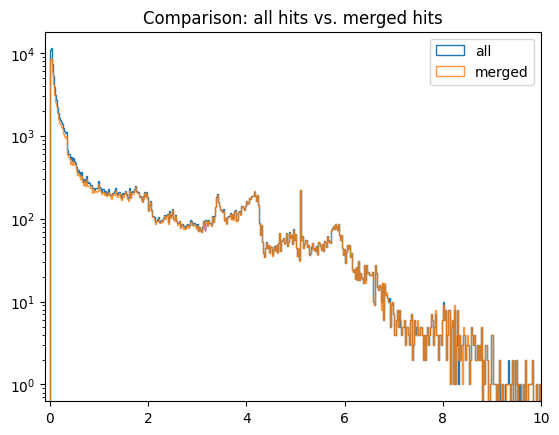

In [63]:
plt.figure()
plt.title("Comparison: all hits vs. merged hits")

bins = np.linspace(0, 10, 500)


plt.hist(energy_dep, bins = bins, histtype = "step", label = "all")
plt.hist(energy_dep_merged, bins = bins, histtype = "step", label = "merged", alpha = 0.8)
#plt.axvline(x = 5.11, color = "black", linestyle = "--", alpha = 0.5, label = "double escape peak (from oxygen, 5.11 MeV)")
#plt.axvline(x = 3.44, color = "black", linestyle = "--", alpha = 0.5, label = "double escape peak (from carbon, 3.44 MeV)")

plt.yscale("log")
plt.xlim(-0.1, 10)
plt.legend()
plt.show()

### Hitfile creation for multiple files

In [2]:
folder_path = r"D:\Study_spectroscopy\HNC_simulations"
folders = os.listdir(folder_path)

for folder in folders[84:]: 
    data_path = folder_path + "/" + folder + "/" + "scintillator_interactions"
    
    file = DetectionDataStorage(folder_path = data_path, primaries_per_spawn = 5e6, max_files = 100)
    file.load_data()
    file.filter_hits(write_hits_to_file = True)

Reading 108 scintillator_interactions.txt-files
Max files reached: 100/100, stopping data collection
Total time used on data collection: 106.96 s

-----------ICODE FILTERING-----------
D:/Study_spectroscopy/HNC_simulations/sim_4_16/gamma_hits.txt successfully created
D:/Study_spectroscopy/HNC_simulations/sim_4_16/neutron_hits.txt successfully created
D:/Study_spectroscopy/HNC_simulations/sim_4_16/all_hits.txt successfully created
Reading 106 scintillator_interactions.txt-files
Max files reached: 100/100, stopping data collection
Total time used on data collection: 26.15 s

-----------ICODE FILTERING-----------
D:/Study_spectroscopy/HNC_simulations/sim_5_0/gamma_hits.txt successfully created
D:/Study_spectroscopy/HNC_simulations/sim_5_0/neutron_hits.txt successfully created
D:/Study_spectroscopy/HNC_simulations/sim_5_0/all_hits.txt successfully created
Reading 104 scintillator_interactions.txt-files
Max files reached: 100/100, stopping data collection
Total time used on data collection:

c:\Users\amibe\OneDrive\Documentos\GitHub\MedicalPhysicsScripts\NOVO\Spectroscopy\Data\mgdraw_output_reader_NOVO_vAMB.py:540: SyntaxWarning: invalid escape sequence '\ '
  """


ValueError: need at least one array to concatenate

### Compare spectroscopy runs

In [3]:
gamma_hits_run_1 = r"d:\Study_spectroscopy\HNC_simulations\sim_0_0\gamma_hits.txt"
gamma_hits_run_2 = r"d:\Study_spectroscopy\HNC_simulations\sim_0_0\neutron_hits.txt"

hit_array_1 = get_gamma_hits(gamma_hits_run_1)
hit_array_2 = get_gamma_hits(gamma_hits_run_2)

energy_dep_1 = hit_array_1[:,7]
energy_dep_2 = hit_array_2[:,7]

regions_1 = hit_array_1[:,-1]
regions_2 = hit_array_2[:,-1]

regions_both = np.concatenate((regions_1, regions_2), axis = 0)

### Find region info

In [4]:
output_file_path = r"d:\Study_spectroscopy\HNC_simulations\sim_0_0\sim_0_0_aa001.out"

# Find the HU group for each mreg
voxel_start_line = 124540 #79721 # In the section === Regions: materials and fields ===, choose the line above the first region
voxel_end_line = 132486 #84675 # Choose the line after the last voxel, obs: not the empty line but the one before. 

# Search up the composition and density of each HU group. 
HU_start_line = 123558#78766 # In the section === Material compositions: ===, choose the line before the first HU-group. 
HU_end_line = 124152#79343 #choose the line after the last element of the last HU group

GT_1 = find_voxel_GT_composition(output_file_path, regions_1, voxel_start_line, voxel_end_line, HU_start_line, HU_end_line)
GT_2 = find_voxel_GT_composition(output_file_path, regions_2, voxel_start_line, voxel_end_line, HU_start_line, HU_end_line)

GT_both = find_voxel_GT_composition(output_file_path, regions_both, voxel_start_line, voxel_end_line, HU_start_line, HU_end_line)

length of regions: 492
length of regions (all): 36944
length of regions: 259
length of regions (all): 17277
length of regions: 508
length of regions (all): 54221


In [5]:
print(GT_1["density"], GT_1["oxygen"], GT_1["carbon"], GT_1["nitrogen"], GT_1["calcium"], GT_1["hydrogen"], GT_1["phosphor"])
print(GT_2["density"], GT_2["oxygen"], GT_2["carbon"], GT_2["nitrogen"], GT_2["calcium"], GT_2["hydrogen"], GT_2["phosphor"])
print(GT_both["density"], GT_both["oxygen"], GT_both["carbon"], GT_both["nitrogen"], GT_both["calcium"], GT_both["hydrogen"], GT_both["phosphor"])


1.0778369918699189 0.20320567073170734 0.17122552032520327 0.012996340386178864 0.008817453861788617 0.5950066463414634 0.005420400325203252
0.9521567567567567 0.19338942084942085 0.16835286100386102 0.009351268223938223 0.001824619691119691 0.6207928957528956 0.0012939059073359075
1.0815785433070866 0.2032099212598425 0.17172595472440944 0.01310506785433071 0.009080902362204725 0.5940367125984252 0.005575796633858269


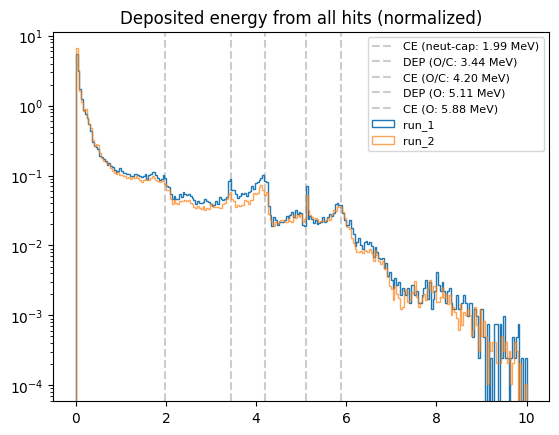

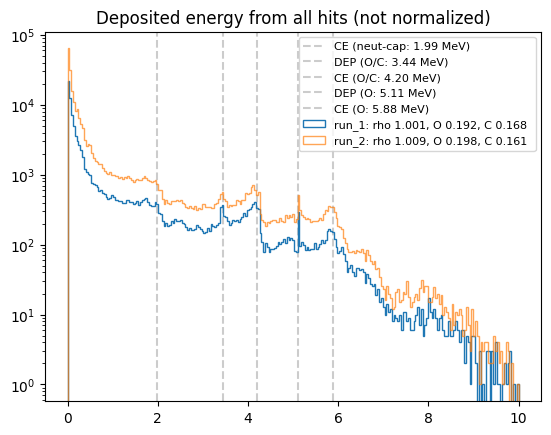

In [36]:
plt.figure()
plt.title("Deposited energy from all hits (normalized)")

bins = np.linspace(0, 10, 250)

plt.axvline(x = 1.99, color = "black", linestyle = "--", alpha = 0.2, label = "CE (neut-cap: 1.99 MeV)")
plt.axvline(x = 3.44, color = "black", linestyle = "--", alpha = 0.2, label = "DEP (O/C: 3.44 MeV)")
plt.axvline(x = 4.20, color = "black", linestyle = "--", alpha = 0.2, label = "CE (O/C: 4.20 MeV)")
plt.axvline(x = 5.11, color = "black", linestyle = "--", alpha = 0.2, label = "DEP (O: 5.11 MeV)")
plt.axvline(x = 5.88, color = "black", linestyle = "--", alpha = 0.2, label = "CE (O: 5.88 MeV)")


plt.hist(energy_dep_1, bins = bins, density = True, histtype = "step", label = "run_1")
plt.hist(energy_dep_2, bins = bins, density = True, histtype = "step", label = "run_2", alpha = 0.7)

plt.yscale("log")
#plt.xlim(-0.1, 10)
plt.legend(fontsize = 8)

plt.show()

plt.figure()
plt.title("Deposited energy from all hits (not normalized)")

bins = np.linspace(0, 10, 250)

plt.axvline(x = 1.99, color = "black", linestyle = "--", alpha = 0.2, label = "CE (neut-cap: 1.99 MeV)")
plt.axvline(x = 3.44, color = "black", linestyle = "--", alpha = 0.2, label = "DEP (O/C: 3.44 MeV)")
plt.axvline(x = 4.20, color = "black", linestyle = "--", alpha = 0.2, label = "CE (O/C: 4.20 MeV)")
plt.axvline(x = 5.11, color = "black", linestyle = "--", alpha = 0.2, label = "DEP (O: 5.11 MeV)")
plt.axvline(x = 5.88, color = "black", linestyle = "--", alpha = 0.2, label = "CE (O: 5.88 MeV)")


plt.hist(energy_dep_1, bins = bins, density = False, histtype = "step", label = f"run_1: rho {np.round(GT_1["density"], 3)}, O {np.round(GT_1["oxygen"], 3)}, C {np.round(GT_1["carbon"], 3)} ")
plt.hist(energy_dep_2, bins = bins, density = False, histtype = "step", label = f"run_2: rho {np.round(GT_2["density"], 3)}, O {np.round(GT_2["oxygen"], 3)}, C {np.round(GT_2["carbon"], 3)} " , alpha = 0.7)

plt.yscale("log")
#plt.xlim(-0.1, 10)
plt.legend(fontsize = 8)

plt.show()

### Find regions info for all and save label

In [ ]:
output_file_path = r"d:\Study_spectroscopy\HNC_simulations\sim_0_0\sim_0_0_aa001.out"

voxel_start_line = 124540 
voxel_end_line = 132486
HU_start_line = 123558
HU_end_line = 124152

folder_path = r"D:\Study_spectroscopy\HNC_simulations"
folders = os.listdir(folder_path)

for folder in folders[:10]:
    gamma_hits =  folder_path + "/" + folder + "/gamma_hits.txt"
    neutron_hits = folder_path + "/" + folder + "/neutron_hits.txt"

    hit_array_gamma = get_gamma_hits(gamma_hits)
    hit_array_neutron = get_gamma_hits(neutron_hits)

    energy_dep_gamma = hit_array_gamma[:,7]
    energy_dep_neutron = hit_array_neutron[:,7]

    regions_gamma = hit_array_gamma[:,-1]
    regions_neutron = hit_array_neutron[:,-1]

    GT_gamma = find_voxel_GT_composition(output_file_path, regions_gamma, voxel_start_line, voxel_end_line, HU_start_line, HU_end_line)
    GT_neutron = find_voxel_GT_composition(output_file_path, regions_neutron, voxel_start_line, voxel_end_line, HU_start_line, HU_end_line) 

### test using bxdraw and protons only for voxel info

In [3]:
file_path_75 = r"d:\Study_spectroscopy\HNC_simulations\sim_0_0\regions"

files_75 = os.listdir(file_path_75)

regions_proton = []
for file_75 in files_75: 

    with open(file_path_75 + "/" + file_75, "r") as f:
        lines = f.readlines()

        for line in lines:
            line = line.split()
            reg_num = int(line[0])
            #if 1073 < reg_num < 1263: # TESTING
            regions_proton.append(reg_num)



In [4]:
output_file_path = r"d:\Study_spectroscopy\HNC_simulations\sim_0_0\sim_0_0_aa001.out"
regions_proton_unique = np.unique(regions_proton)
print(len(regions_proton))
print(len(regions_proton_unique))

45259602
2209


In [5]:
output_file_path = r"d:\Study_spectroscopy\HNC_simulations\sim_0_0\sim_0_0_aa001.out"

voxel_start_line = 124540 
voxel_end_line = 132486
HU_start_line = 123558
HU_end_line = 124152

GT_proton = find_voxel_GT_composition(output_file_path, regions_proton_unique, voxel_start_line, voxel_end_line, HU_start_line, HU_end_line) 

length of regions: 2209
length of regions (all): 2209


In [6]:
print(GT_proton["density"], GT_proton["oxygen"], GT_proton["carbon"], GT_proton["nitrogen"], GT_proton["calcium"], GT_proton["hydrogen"], GT_proton["phosphor"])

0.9960807102761431 0.23385589497510184 0.14212932235853326 0.03410655521502942 0.015830935717519236 0.5492180488909009 0.009579306459936623


In [7]:
regions_proton_unique_int = regions_proton_unique.astype(int)
regions_proton_int = np.array(regions_proton).astype(int)

In [8]:
print(max(regions_proton_unique_int))
print(min(regions_proton_unique_int))


3973
1


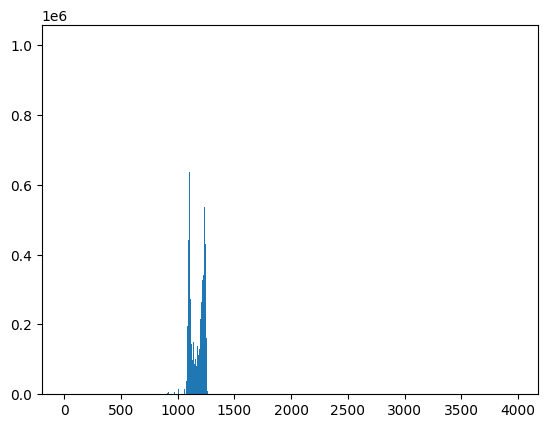

In [21]:
bins = np.linspace(1, 3973, 3973)


plt.figure()
plt.hist(regions_proton_int, bins = bins)
plt.show()

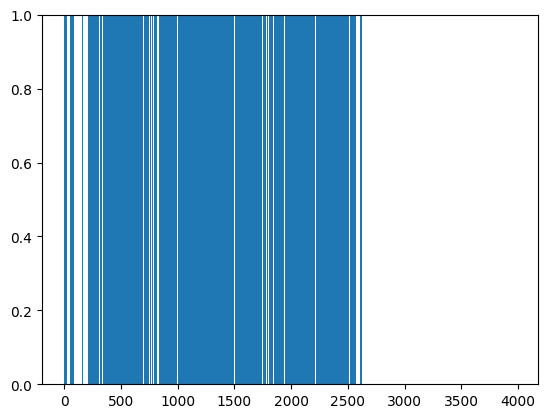

In [13]:
plt.figure()
plt.hist(regions_proton_int, bins = bins)
plt.ylim(0,1)
plt.show()

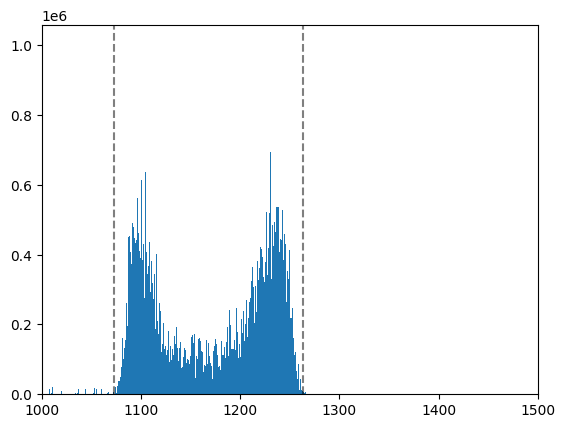

In [20]:
plt.figure()
plt.hist(regions_proton_int, bins = bins)
plt.xlim(1000, 1500)
plt.axvline(x = 1073, color = "black", linestyle = "--", alpha = 0.5)
plt.axvline(x = 1263, color = "black", linestyle = "--", alpha = 0.5)
plt.show()

### Test using PG/FN production - how different is the result?

In [9]:
file_path_76 = r"d:\Study_spectroscopy\HNC_simulations\sim_0_0\regions_PG_FN_prod"

files_76 = os.listdir(file_path_76)

regions_PG_FN = []
for file_76 in files_76: 

    with open(file_path_76 + "/" + file_76, "r") as f:
        lines = f.readlines()

        for line in lines:
            line = line.split()
            jtrack = int(line[1])
            reg_num = int(line[2])

            if jtrack == 1 or jtrack == -2:
                regions_PG_FN.append(reg_num)
            

In [10]:
regions_PG_FN_unique = np.unique(regions_PG_FN)
print(len(regions_PG_FN))
print(len(regions_PG_FN_unique))

regions_PG_FN_int = np.array(regions_PG_FN).astype(int)
print(max(regions_PG_FN_unique))
print(min(regions_PG_FN_unique))

2552031
2302
3973
1


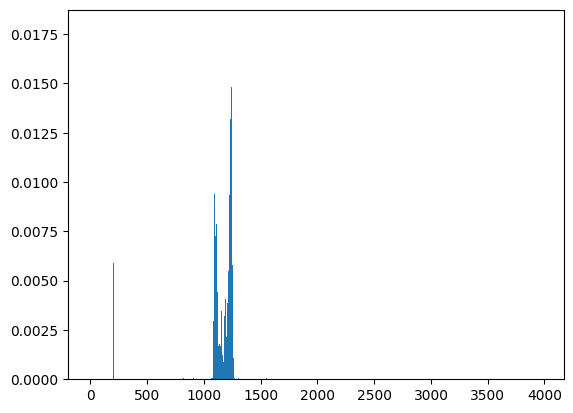

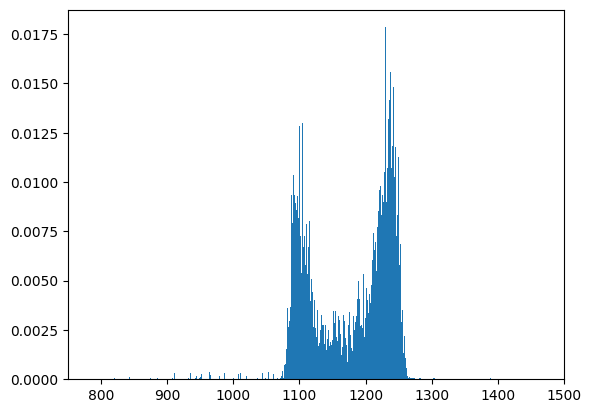

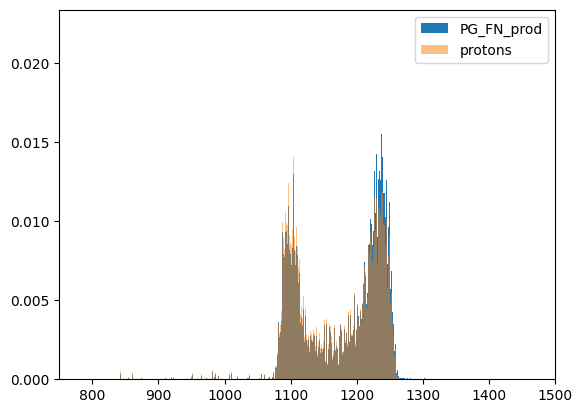

In [ ]:
bins = np.linspace(1, 3973, 3973)

counts, bin_edges = np.histogram(regions_PG_FN_int, bins = bins, density = True)
counts_protons, bin_edges_protons = np.histogram(regions_proton_int, bins = bins, density = True)

plt.figure()
plt.bar(bin_edges[:-1], counts, width = np.diff(bin_edges), align='edge')
plt.show()


plt.figure()
plt.bar(bin_edges[:-1], counts, width = np.diff(bin_edges), align='edge')
plt.xlim(750, 1500)
plt.show()

plt.figure()
plt.bar(bin_edges[:-1], counts, width = np.diff(bin_edges), align='edge', label = "PG_FN_prod")
plt.bar(bin_edges_protons[:-1], counts_protons, width = np.diff(bin_edges), align='edge', label = "protons", alpha = 0.5)
plt.legend()
plt.xlim(750, 1500)
plt.show()

In [47]:


thres = 0.03 * max(counts)
validated_bins = []
validated_bins_counts = []

for i in range(len(counts)):
    count = counts[i]
    bin = bin_edges[i]


    if count > thres:
        validated_bins.append(bin)
        validated_bins_counts.append(count)
    else:
        validated_bins_counts.append(0.0)


print("length before thresholding (PG/FN): ", len(counts))
print("length after thresholding (PG/FN): ", len(validated_bins))
print(min(validated_bins)) 

length before thresholding (PG/FN):  3972
length after thresholding (PG/FN):  185
203.0


In [48]:
thres = 0.03 * max(counts_protons)
validated_bins_protons = []
validated_bins_counts_protons = []

for i in range(len(counts_protons)):
    count = counts_protons[i]
    bin = bin_edges_protons[i]


    if count > thres:
        validated_bins_protons.append(bin)
        validated_bins_counts_protons.append(count)
    else:
        validated_bins_counts_protons.append(0.0)


print("length before thresholding (PG/FN): ", len(counts_protons))
print("length after thresholding (PG/FN): ", len(validated_bins_protons))
print(min(validated_bins_protons)) 

length before thresholding (PG/FN):  3972
length after thresholding (PG/FN):  184
203.0


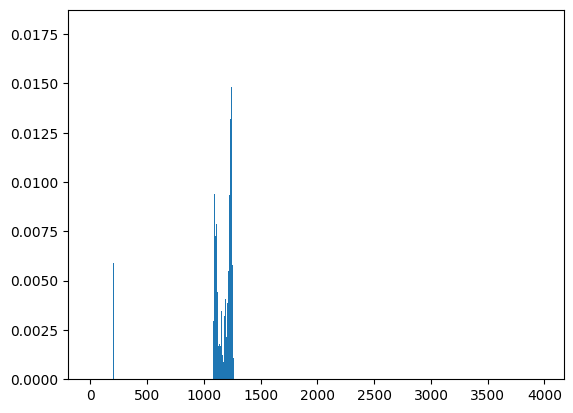

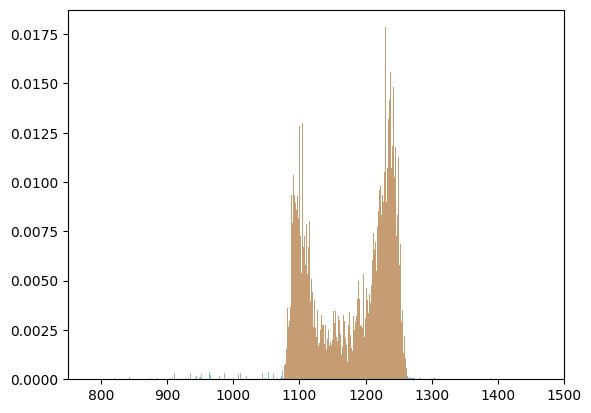

In [43]:
plt.figure()
plt.bar(bin_edges[:-1], validated_bins_counts, width = np.diff(bin_edges), align='edge')
plt.show()
plt.figure()
plt.bar(bin_edges[:-1], counts, width = np.diff(bin_edges), align='edge', label = "original", alpha = 0.5)
plt.bar(bin_edges[:-1], validated_bins_counts, width = np.diff(bin_edges), align='edge', label = "thresholded", alpha = 0.5)
plt.xlim(750, 1500)
plt.show()

In [57]:
validated_bins_protons = np.array(validated_bins_protons).astype(int)
validated_bins_protons = list(validated_bins_protons)
validated_bins = np.array(validated_bins).astype(int)
validated_bins= list(validated_bins)



GT_proton = find_voxel_GT_composition(output_file_path, regions_proton, voxel_start_line, voxel_end_line, HU_start_line, HU_end_line) 
GT_PG_FN = find_voxel_GT_composition(output_file_path, regions_PG_FN, voxel_start_line, voxel_end_line, HU_start_line, HU_end_line) 
GT_proton_validated_bins = find_voxel_GT_composition(output_file_path, validated_bins_protons , voxel_start_line, voxel_end_line, HU_start_line, HU_end_line) 
GT_PG_FN_validated_bins = find_voxel_GT_composition(output_file_path, validated_bins , voxel_start_line, voxel_end_line, HU_start_line, HU_end_line) 

length of regions: 2209
length of regions (all): 45259602
length of regions: 2302
length of regions (all): 2552031
length of regions: 184
length of regions (all): 184
length of regions: 185
length of regions (all): 185


In [16]:
print(np.round(GT_proton["density"],4), np.round(GT_proton["oxygen"],4), np.round(GT_proton["carbon"],4), np.round(GT_proton["nitrogen"],4), np.round(GT_proton["calcium"],4), np.round(GT_proton["hydrogen"],4), np.round(GT_proton["phosphor"],4))
print(np.round(GT_PG_FN["density"],4), np.round(GT_PG_FN["oxygen"],4), np.round(GT_PG_FN["carbon"],4), np.round(GT_PG_FN["nitrogen"],4), np.round(GT_PG_FN["calcium"],4), np.round(GT_PG_FN["hydrogen"],4), np.round(GT_PG_FN["phosphor"],4))

0.9961 0.2339 0.1421 0.0341 0.0158 0.5492 0.0096
1.0852 0.2248 0.1527 0.0198 0.0195 0.5289 0.0117


In [59]:
print(np.round(GT_proton_validated_bins["density"],4), np.round(GT_proton_validated_bins["oxygen"],4), np.round(GT_proton_validated_bins["carbon"],4), np.round(GT_proton_validated_bins["nitrogen"],4), np.round(GT_proton_validated_bins["calcium"],4), np.round(GT_proton_validated_bins["hydrogen"],4), np.round(GT_proton_validated_bins["phosphor"],4))
print(np.round(GT_PG_FN_validated_bins["density"],4), np.round(GT_PG_FN_validated_bins["oxygen"],4), np.round(GT_PG_FN_validated_bins["carbon"],4), np.round(GT_PG_FN_validated_bins["nitrogen"],4), np.round(GT_PG_FN_validated_bins["calcium"],4), np.round(GT_PG_FN_validated_bins["hydrogen"],4), np.round(GT_PG_FN_validated_bins["phosphor"],4))

0.9687 0.1675 0.1937 0.0072 0.0 0.6251 0.0002
0.9692 0.1681 0.193 0.0072 0.0 0.6252 0.0002
